# Data Exploration — Czech Energy (OWID)

Exploratory analysis of Czech energy data from the [Our World in Data energy dataset](https://github.com/owid/energy-data).

This notebook answers:
- How has Czech energy consumption changed over time?
- What is the current fossil fuel dependence?
- How do Czech trends compare to neighbouring countries?
- What does this mean for transport electrification?

→ Continue to [02-input-output-model.ipynb](02-input-output-model.ipynb) for the IO analysis.

In [31]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
%matplotlib inline
print('Setup complete.')

Setup complete.


## 1. Load OWID Energy Data

In [32]:
OWID_URL = 'https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv'
print('Fetching OWID energy data...')
df_all = pd.read_csv(OWID_URL)
print(f'Loaded: {df_all.shape[0]:,} rows, {df_all.shape[1]} columns, {df_all.country.nunique()} countries')

cz = df_all[df_all['country'] == 'Czechia'].copy().sort_values('year').reset_index(drop=True)
print(f'Czech data: {len(cz)} years ({cz.year.min()}–{cz.year.max()})')
cz[['year','oil_consumption','coal_consumption','gas_consumption',
     'electricity_demand','renewables_share_energy','carbon_intensity_elec']].tail(8)

Fetching OWID energy data...
Loaded: 23,377 rows, 130 columns, 314 countries
Czech data: 61 years (1965–2025)


,year,oil_consumption,coal_consumption,gas_consumption,electricity_demand,renewables_share_energy,carbon_intensity_elec
53,2018,116.114,186.013,79.828,72.93,6.179,532.59
54,2019,117.604,167.363,83.250,72.62,6.744,503.50
55,2020,102.484,145.435,84.624,69.95,7.539,460.18
56,2021,112.964,150.688,90.694,72.58,7.275,471.79
57,2022,108.507,154.261,73.764,70.20,7.496,488.36
58,2023,107.824,125.104,66.975,66.62,8.386,442.61
59,2024,112.905,99.847,66.890,66.15,9.746,414.23
60,2025,NaN,NaN,NaN,68.04,NaN,401.46


## 2. Summary Statistics

In [33]:
cols = ['oil_consumption','coal_consumption','gas_consumption',
        'electricity_demand','renewables_share_energy','carbon_intensity_elec']
cz[cz['year'] >= 2000][cols].describe().round(1)

,oil_consumption,coal_consumption,gas_consumption,electricity_demand,renewables_share_energy,carbon_intensity_elec
count,25.0,25.0,25.0,26.0,25.0,26.0
mean,108.9,199.7,82.8,69.2,4.7,571.0
std,7.2,40.8,7.6,2.7,2.6,95.9
min,94.4,99.8,66.9,62.9,1.2,401.5
25%,103.5,186.0,79.2,68.0,1.9,509.5
50%,108.3,206.1,83.4,69.5,5.2,563.5
75%,115.3,237.6,89.6,71.0,6.5,638.7
max,119.2,246.7,93.8,72.9,9.7,767.1


## 3. Czech Energy Trends (2000–present)

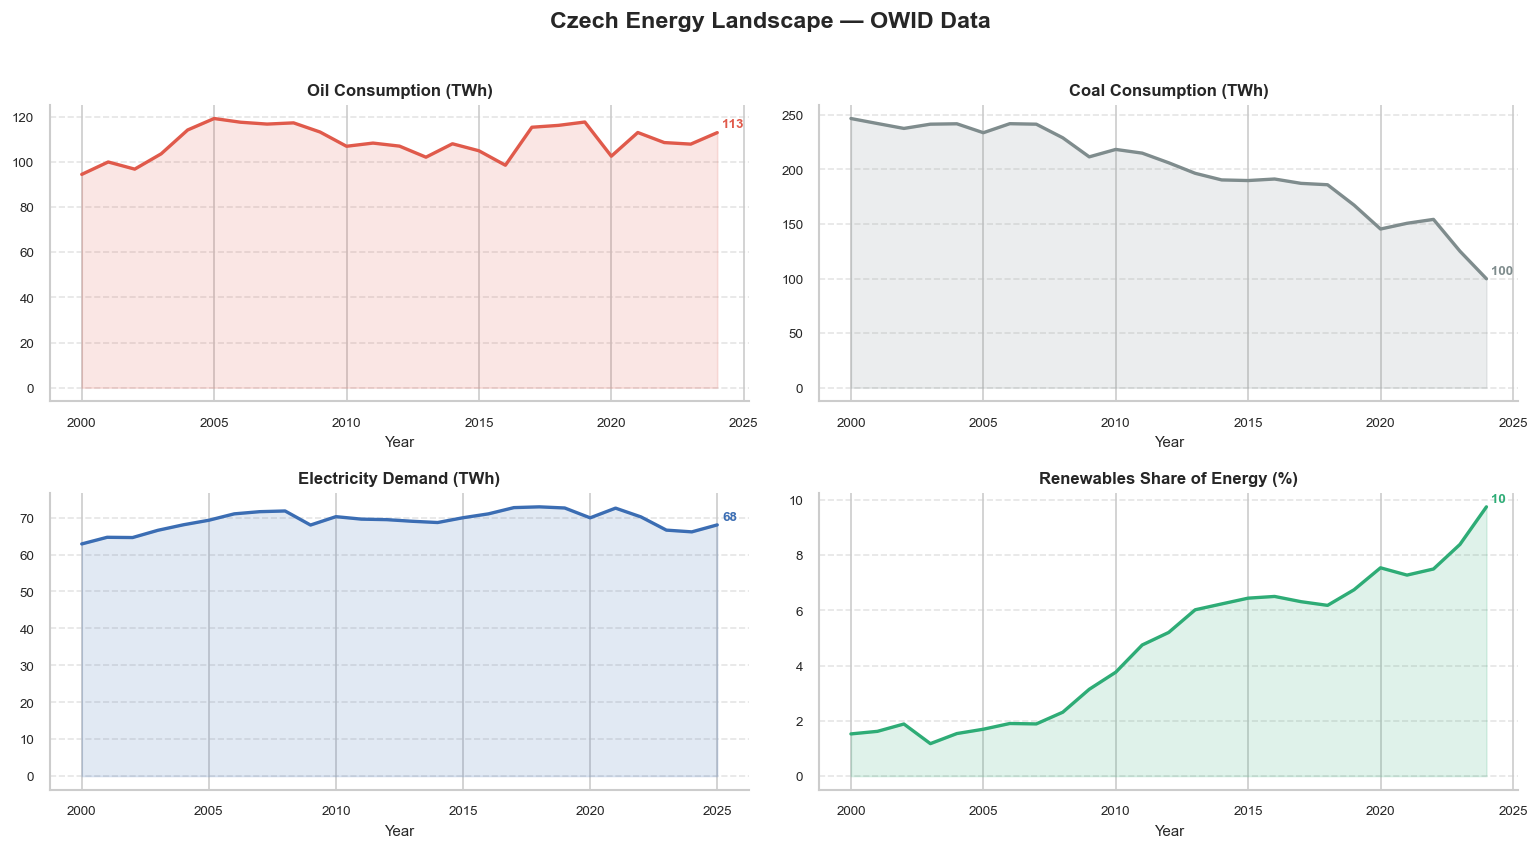

In [34]:
from src.viz.plotting import plot_czech_energy_trends
fig = plot_czech_energy_trends(cz, start_year=2000)
plt.show()

## 4. Fossil Fuel Mix Over Time

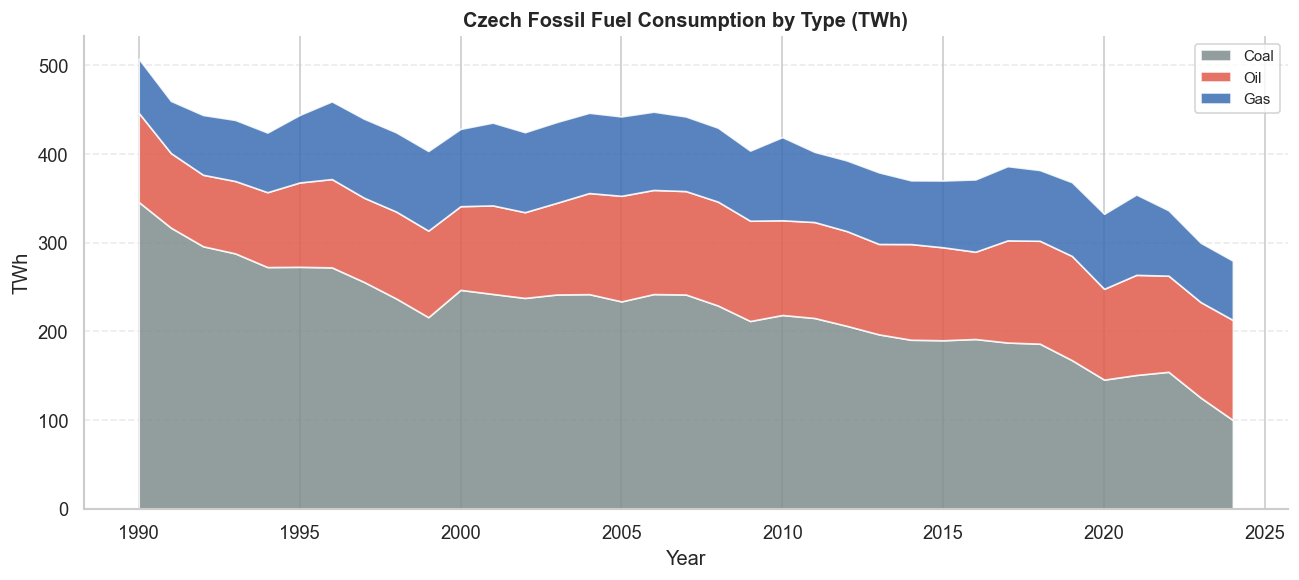

Year 2024: total fossil = 280 TWh, oil share = 40.4%


In [35]:
fuel_cols = ['coal_consumption', 'oil_consumption', 'gas_consumption']
df_plot = cz[cz['year'] >= 1990].dropna(subset=fuel_cols)

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(
    df_plot['year'],
    df_plot['coal_consumption'], df_plot['oil_consumption'], df_plot['gas_consumption'],
    labels=['Coal', 'Oil', 'Gas'],
    colors=['#7F8C8D', '#E05A4B', '#3B6DB3'], alpha=0.85
)
ax.set_title('Czech Fossil Fuel Consumption by Type (TWh)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('TWh')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

last = df_plot.iloc[-1]
total = last[fuel_cols].sum()
print(f"Year {int(last['year'])}: total fossil = {total:.0f} TWh, oil share = {last['oil_consumption']/total*100:.1f}%")

## 5. Czechia vs. Neighbours — Carbon Intensity of Electricity

/var/folders/wf/7_3zr1vx1k7dfytsl5v19p840000gn/T/ipykernel_4964/3645862128.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/Users/marta/Documents/GitHub/input_output/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


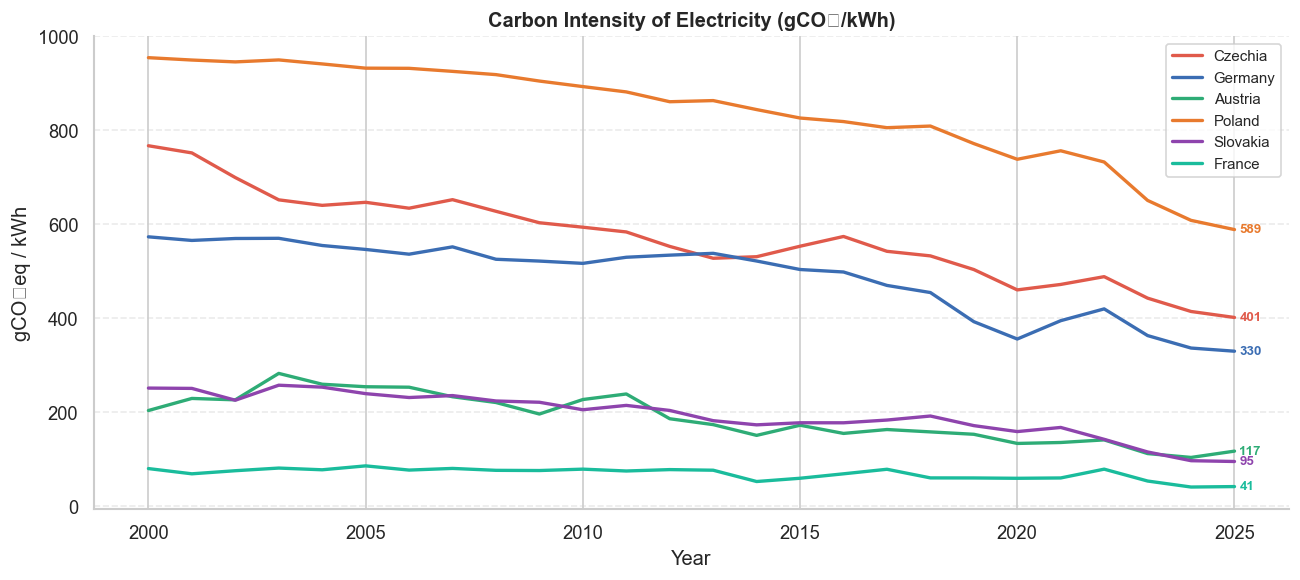

In [36]:
COUNTRIES = ['Czechia', 'Germany', 'Austria', 'Poland', 'Slovakia', 'France']
COLORS   = ['#E05A4B', '#3B6DB3', '#2EAC76', '#E87A2E', '#8E44AD', '#1ABC9C']

fig, ax = plt.subplots(figsize=(11, 5))
for country, color in zip(COUNTRIES, COLORS):
    sub = df_all[(df_all['country'] == country) & (df_all['year'] >= 2000)].dropna(subset=['carbon_intensity_elec'])
    if not sub.empty:
        ax.plot(sub['year'], sub['carbon_intensity_elec'], label=country, color=color, linewidth=2)
        last_row = sub.iloc[-1]
        ax.annotate(f"{last_row['carbon_intensity_elec']:.0f}",
                    xy=(last_row['year'], last_row['carbon_intensity_elec']),
                    color=color, fontsize=8, fontweight='bold',
                    xytext=(3, 0), textcoords='offset points', va='center')

ax.set_title('Carbon Intensity of Electricity (gCO\u2082/kWh)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('gCO\u2082eq / kWh')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Oil Consumption — Baseline for Electrification Scenario

The IO model in notebook 02 uses Czech oil consumption to size the Oil & Fuel Refining sector and calibrate the electrification shock.

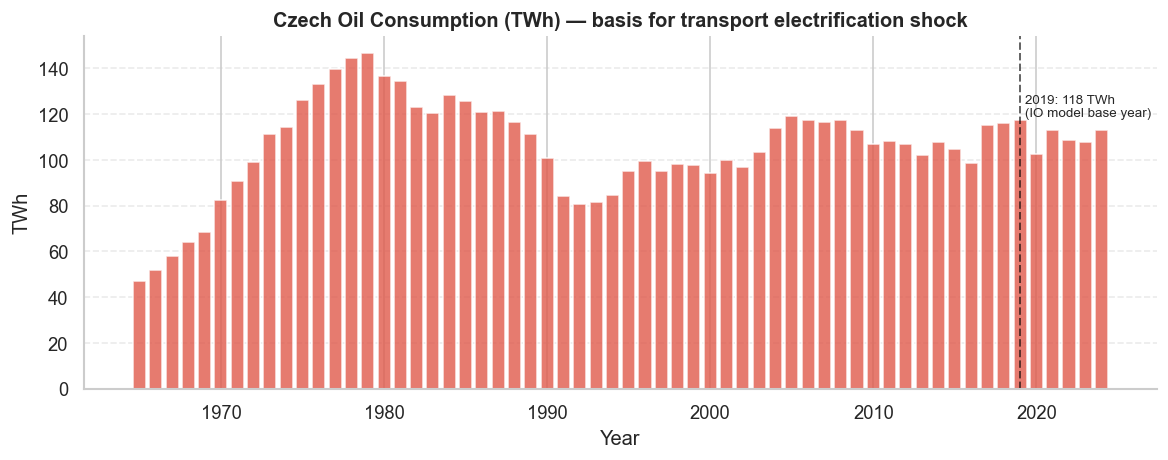

2019 Czech oil: 118 TWh
Road transport share (~62%): 73 TWh  →  ~131 bCZK fuel demand at stake


In [37]:
oil_data = cz.dropna(subset=['oil_consumption'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(oil_data['year'], oil_data['oil_consumption'], color='#E05A4B', alpha=0.8, width=0.8)
ax.set_title('Czech Oil Consumption (TWh) — basis for transport electrification shock', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('TWh')
ax.grid(axis='y', linestyle='--', alpha=0.4)

val_2019 = oil_data[oil_data['year'] == 2019]['oil_consumption'].values
if len(val_2019):
    ax.axvline(2019, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(2019.3, val_2019[0], f'2019: {val_2019[0]:.0f} TWh\n(IO model base year)', fontsize=8, va='bottom')

plt.tight_layout(); plt.show()

if len(val_2019):
    road_twh = val_2019[0] * 0.62
    print(f'2019 Czech oil: {val_2019[0]:.0f} TWh')
    print(f'Road transport share (~62%): {road_twh:.0f} TWh  →  ~{road_twh*1.8:.0f} bCZK fuel demand at stake')

## 7. Renewables Growth

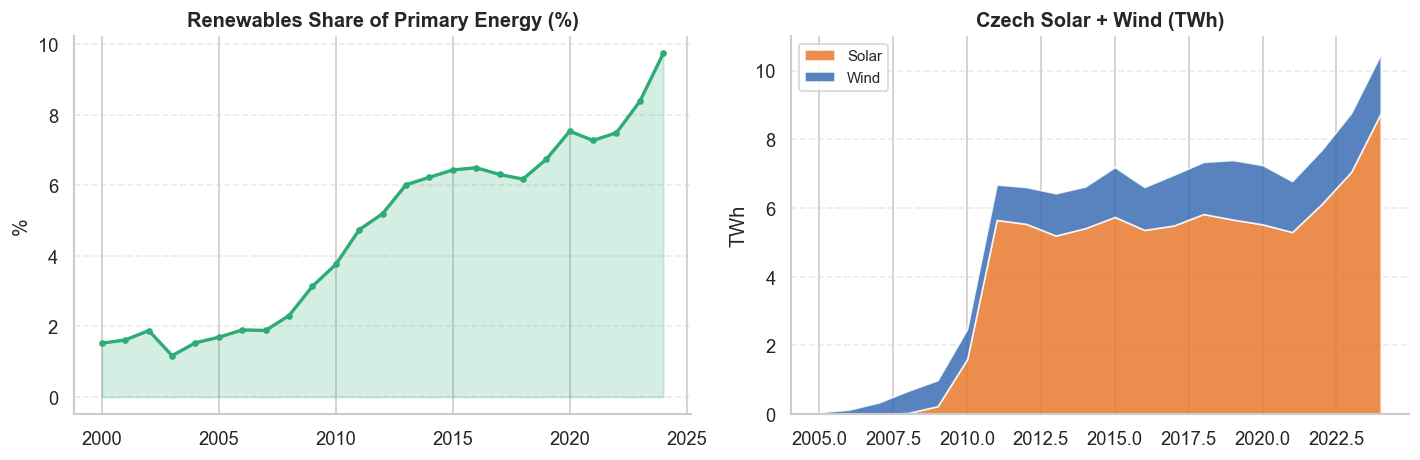

In [38]:
ren_data = cz[cz['year'] >= 2000].dropna(subset=['renewables_consumption'])
sw_data  = cz[cz['year'] >= 2005].dropna(subset=['solar_consumption','wind_consumption'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ren_data['year'], ren_data['renewables_share_energy'], color='#2EAC76', linewidth=2, marker='o', markersize=3)
axes[0].fill_between(ren_data['year'], ren_data['renewables_share_energy'], alpha=0.2, color='#2EAC76')
axes[0].set_title('Renewables Share of Primary Energy (%)', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].stackplot(sw_data['year'],
                  sw_data['solar_consumption'], sw_data['wind_consumption'],
                  labels=['Solar','Wind'], colors=['#E87A2E','#3B6DB3'], alpha=0.85)
axes[1].set_title('Czech Solar + Wind (TWh)', fontweight='bold')
axes[1].set_ylabel('TWh'); axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()

## 8. Key Takeaways

| Metric | Value (latest) | Trend |
|--------|---------------|-------|
| Oil consumption | ~100–120 TWh/yr | Stable |
| Coal consumption | ~150–250 TWh/yr | Declining |
| Carbon intensity of electricity | ~350–450 gCO\u2082/kWh | Declining |
| Renewables share | ~15–20% | Growing |

**For the IO model:**
- Oil sector gross output calibrated from OWID `oil_consumption` 2019
- Electricity sector calibrated from OWID `electricity_demand` 2019
- Electrification shock = replacing ~62% of Czech oil (road transport) with electricity

**Next:** [02-input-output-model.ipynb](02-input-output-model.ipynb)